In [3]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

drive_path = '/content/drive/MyDrive/ppi/ppi' # Updated path to look inside the nested 'ppi' directory

# Check if the directory exists
if not os.path.exists(drive_path):
    print(f"The directory '{drive_path}' does not exist.")
else:
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        item_path = os.path.join(drive_path, item)
        if os.path.isdir(item_path):
            print(f"[DIR] {item}")
        else:
            print(f"[FILE] {item}")

Contents of '/content/drive/MyDrive/ppi/ppi':
[FILE] ppi-feats.npy
[FILE] ppi-class_map.json
[FILE] ppi-G.json
[FILE] ppi-id_map.json
[FILE] ppi-walks.txt


### Unsupervised Training for GraphSAGE_Mean (Feature Reconstruction)

For unsupervised learning, we'll train the `GraphSAGE_Mean` model to reconstruct its input features. This means the output dimension of the model will be the same as the input feature dimension. We will use Mean Squared Error (MSE) as the loss function.

In [18]:
model_mean_unsupervised = GraphSAGE_Mean(
    in_dim=features.shape[1],
    hidden_dim=128, # Using the same hidden dimension as before
    out_dim=features.shape[1] # Output dimension for feature reconstruction
).to(device)

optimizer_mean_unsupervised = torch.optim.Adam(model_mean_unsupervised.parameters(), lr=0.001)
loss_fn_mean_unsupervised = torch.nn.MSELoss()

mean_unsupervised_losses = []

print("Starting unsupervised training for GraphSAGE_Mean (Feature Reconstruction)...")
for epoch in range(200):
    model_mean_unsupervised.train()
    out_unsupervised = model_mean_unsupervised(features, adj)

    # Loss is between the reconstructed features (output) and the original features (target)
    loss = loss_fn_mean_unsupervised(out_unsupervised, features)

    optimizer_mean_unsupervised.zero_grad()
    loss.backward()
    optimizer_mean_unsupervised.step()

    mean_unsupervised_losses.append(loss.item())

    if epoch % 20 == 0 or epoch == 199:
        print(f"Epoch {epoch} (Mean Unsupervised) | Loss: {loss.item():.6f}")

final_loss_mean_unsupervised = mean_unsupervised_losses[-1]
print(f"\nFinal MSE Loss for GraphSAGE_Mean (Unsupervised): {final_loss_mean_unsupervised:.6f}")

Starting unsupervised training for GraphSAGE_Mean (Feature Reconstruction)...
Epoch 0 (Mean Unsupervised) | Loss: 0.021368
Epoch 20 (Mean Unsupervised) | Loss: 0.015192
Epoch 40 (Mean Unsupervised) | Loss: 0.010734
Epoch 60 (Mean Unsupervised) | Loss: 0.005762
Epoch 80 (Mean Unsupervised) | Loss: 0.002299
Epoch 100 (Mean Unsupervised) | Loss: 0.000722
Epoch 120 (Mean Unsupervised) | Loss: 0.000236
Epoch 140 (Mean Unsupervised) | Loss: 0.000117
Epoch 160 (Mean Unsupervised) | Loss: 0.000080
Epoch 180 (Mean Unsupervised) | Loss: 0.000059
Epoch 199 (Mean Unsupervised) | Loss: 0.000047

Final MSE Loss for GraphSAGE_Mean (Unsupervised): 0.000047


### Unsupervised Training for GraphSAGE_GCN (Feature Reconstruction)

Similarly, we'll apply unsupervised learning to the `GraphSAGE_GCN` model by training it to reconstruct its input features using MSE loss.

In [19]:
model_gcn_unsupervised = GraphSAGE_GCN(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=features.shape[1] # Output dimension for feature reconstruction
).to(device)

optimizer_gcn_unsupervised = torch.optim.Adam(model_gcn_unsupervised.parameters(), lr=0.001)
loss_fn_gcn_unsupervised = torch.nn.MSELoss()

gcn_unsupervised_losses = []

print("Starting unsupervised training for GraphSAGE_GCN (Feature Reconstruction)...")
for epoch in range(200):
    model_gcn_unsupervised.train()
    out_unsupervised = model_gcn_unsupervised(features, adj)

    # Loss is between the reconstructed features (output) and the original features (target)
    loss = loss_fn_gcn_unsupervised(out_unsupervised, features)

    optimizer_gcn_unsupervised.zero_grad()
    loss.backward()
    optimizer_gcn_unsupervised.step()

    gcn_unsupervised_losses.append(loss.item())

    if epoch % 20 == 0 or epoch == 199:
        print(f"Epoch {epoch} (GCN Unsupervised) | Loss: {loss.item():.6f}")

final_loss_gcn_unsupervised = gcn_unsupervised_losses[-1]
print(f"\nFinal MSE Loss for GraphSAGE_GCN (Unsupervised): {final_loss_gcn_unsupervised:.6f}")

Starting unsupervised training for GraphSAGE_GCN (Feature Reconstruction)...
Epoch 0 (GCN Unsupervised) | Loss: 0.021959
Epoch 20 (GCN Unsupervised) | Loss: 0.017770
Epoch 40 (GCN Unsupervised) | Loss: 0.017481
Epoch 60 (GCN Unsupervised) | Loss: 0.017183
Epoch 80 (GCN Unsupervised) | Loss: 0.016790
Epoch 100 (GCN Unsupervised) | Loss: 0.016354
Epoch 120 (GCN Unsupervised) | Loss: 0.015949
Epoch 140 (GCN Unsupervised) | Loss: 0.015608
Epoch 160 (GCN Unsupervised) | Loss: 0.015333
Epoch 180 (GCN Unsupervised) | Loss: 0.015116
Epoch 199 (GCN Unsupervised) | Loss: 0.014955

Final MSE Loss for GraphSAGE_GCN (Unsupervised): 0.014955


### Comparison of Unsupervised Losses

Here are the final unsupervised (feature reconstruction) losses for both models:

In [20]:
print(f"Final MSE Loss for GraphSAGE_Mean (Unsupervised): {final_loss_mean_unsupervised:.6f}")
print(f"Final MSE Loss for GraphSAGE_GCN (Unsupervised): {final_loss_gcn_unsupervised:.6f}")

Final MSE Loss for GraphSAGE_Mean (Unsupervised): 0.000047
Final MSE Loss for GraphSAGE_GCN (Unsupervised): 0.014955


### Plotting Unsupervised Training Losses

Let's visualize how the MSE loss evolved during unsupervised training for both models.

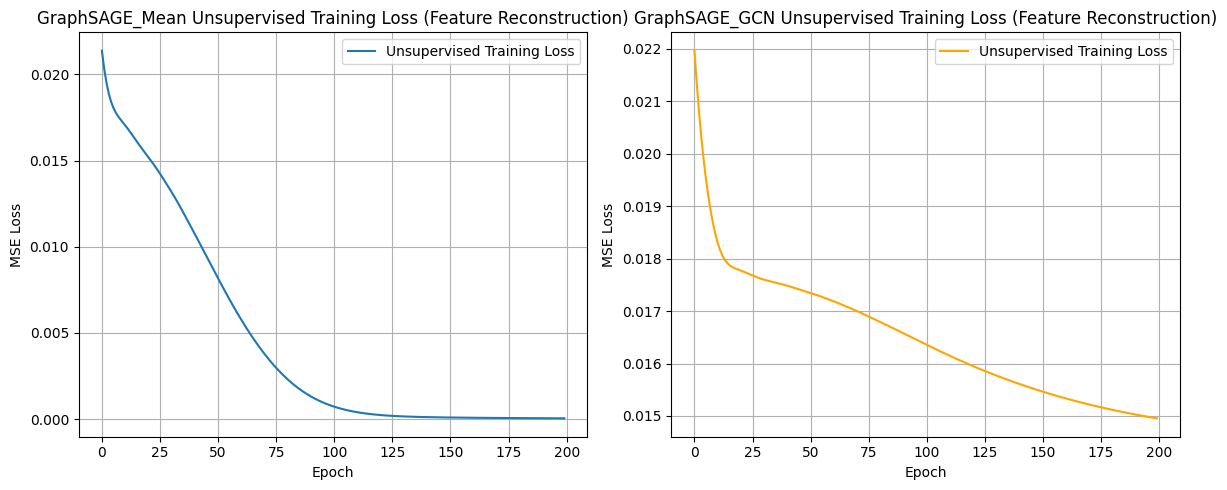

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plotting loss for GraphSAGE_Mean Unsupervised
plt.subplot(1, 2, 1)
plt.plot(mean_unsupervised_losses, label='Unsupervised Training Loss')
plt.title('GraphSAGE_Mean Unsupervised Training Loss (Feature Reconstruction)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

# Plotting loss for GraphSAGE_GCN Unsupervised
plt.subplot(1, 2, 2)
plt.plot(gcn_unsupervised_losses, label='Unsupervised Training Loss', color='orange')
plt.title('GraphSAGE_GCN Unsupervised Training Loss (Feature Reconstruction)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GraphSAGE_Mean(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        self.fc1 = nn.Linear(in_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim * 2, out_dim)

    def aggregate(self, x, adj):
        return torch.matmul(adj, x)

    def forward(self, x, adj):

        neigh = self.aggregate(x, adj)
        h = torch.cat([x, neigh], dim=1)
        h = F.relu(self.fc1(h))

        neigh = self.aggregate(h, adj)
        h = torch.cat([h, neigh], dim=1)
        h = self.fc2(h)

        return h

In [7]:
class GraphSAGE_GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def aggregate(self, x, adj):
        return torch.matmul(adj, x)

    def forward(self, x, adj):

        h = self.aggregate(x, adj)
        h = F.relu(self.fc1(h))

        h = self.aggregate(h, adj)
        h = self.fc2(h)

        return h

In [8]:
import numpy as np
import json
import torch
import scipy.sparse # Import scipy.sparse for efficient degree calculation

data_dir = "/content/drive/MyDrive/ppi/ppi"

# features
features = np.load(f"{data_dir}/ppi-feats.npy")

# graph
with open(f"{data_dir}/ppi-G.json") as f:
    graph = json.load(f)

# id map
with open(f"{data_dir}/ppi-id_map.json") as f:
    id_map = json.load(f)

# labels
with open(f"{data_dir}/ppi-class_map.json") as f:
    class_map = json.load(f)

print("features shape:", features.shape)

num_nodes = len(id_map)

# --- Sparse Adjacency Matrix Construction and Normalization ---
row_indices = []
col_indices = []
degrees = np.zeros(num_nodes, dtype=np.float32)

# Collect edges and calculate degrees
for edge in graph["links"]:
    src = id_map[str(edge["source"])]
    dst = id_map[str(edge["target"])]

    # Add both directions for an undirected graph
    row_indices.append(src)
    col_indices.append(dst)
    degrees[src] += 1

    row_indices.append(dst)
    col_indices.append(src)
    degrees[dst] += 1

# Calculate inverse degrees for normalization: 1/degree
inv_degrees = np.where(degrees > 0, 1.0 / degrees, 0.0)

# Apply normalization to the data values
# Each entry (row_idx, col_idx) will have a value of 1/degree[row_idx]
normalized_values = [inv_degrees[row_indices[k]] for k in range(len(row_indices))]

# Create sparse COO tensor
adj_indices = torch.tensor([row_indices, col_indices], dtype=torch.long)
adj_values = torch.tensor(normalized_values, dtype=torch.float32)

# Ensure the sparse tensor is created correctly with the specified size
adj = torch.sparse_coo_tensor(adj_indices, adj_values, (num_nodes, num_nodes), dtype=torch.float32)

# Coalesce to handle potential duplicate entries (though not expected here with simple undirected graph)
adj = adj.coalesce()
# --- End Sparse Adjacency Matrix Construction and Normalization ---

num_classes = len(next(iter(class_map.values())))

labels = np.zeros((num_nodes, num_classes))

for node, label in class_map.items():
    labels[id_map[node]] = label

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

features = torch.tensor(features, dtype=torch.float32).to(device)
adj = adj.to(device) # Move sparse tensor to device
labels = torch.tensor(labels, dtype=torch.float32).to(device)

print("Features shape:", features.shape)
print("Adj shape:", adj.shape, "(sparse tensor)")
print("Labels shape:", labels.shape)


features shape: (56944, 50)
Features shape: torch.Size([56944, 50])
Adj shape: torch.Size([56944, 56944]) (sparse tensor)
Labels shape: torch.Size([56944, 121])


In [9]:
model = GraphSAGE_Mean(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

mean_losses = []
mean_accuracies = []

for epoch in range(200):

    model.train()

    out = model(features, adj)

    loss = torch.nn.functional.binary_cross_entropy_with_logits(
        out, labels
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Calculate accuracy
    # Apply sigmoid to logits to get probabilities
    probabilities = torch.sigmoid(out)
    # Threshold probabilities to get binary predictions
    predictions = (probabilities > 0.5).float()
    # Calculate element-wise equality and sum up correct predictions
    correct_predictions = (predictions == labels).float().sum()
    # Total number of labels
    total_labels = labels.numel()
    # Calculate accuracy as a percentage of correctly predicted individual labels
    accuracy = (correct_predictions / total_labels).item()

    mean_losses.append(loss.item())
    mean_accuracies.append(accuracy)

    print(f"Epoch {epoch} | Loss {loss.item():.4f} | Accuracy {accuracy:.4f}")

Epoch 0 | Loss 0.6931 | Accuracy 0.5049
Epoch 1 | Loss 0.6909 | Accuracy 0.5388
Epoch 2 | Loss 0.6888 | Accuracy 0.5706
Epoch 3 | Loss 0.6866 | Accuracy 0.6047
Epoch 4 | Loss 0.6843 | Accuracy 0.6399
Epoch 5 | Loss 0.6819 | Accuracy 0.6692
Epoch 6 | Loss 0.6795 | Accuracy 0.6955
Epoch 7 | Loss 0.6769 | Accuracy 0.7126
Epoch 8 | Loss 0.6741 | Accuracy 0.7220
Epoch 9 | Loss 0.6712 | Accuracy 0.7284
Epoch 10 | Loss 0.6681 | Accuracy 0.7348
Epoch 11 | Loss 0.6649 | Accuracy 0.7380
Epoch 12 | Loss 0.6615 | Accuracy 0.7388
Epoch 13 | Loss 0.6580 | Accuracy 0.7390
Epoch 14 | Loss 0.6543 | Accuracy 0.7391
Epoch 15 | Loss 0.6505 | Accuracy 0.7392
Epoch 16 | Loss 0.6465 | Accuracy 0.7392
Epoch 17 | Loss 0.6424 | Accuracy 0.7392
Epoch 18 | Loss 0.6382 | Accuracy 0.7393
Epoch 19 | Loss 0.6339 | Accuracy 0.7393
Epoch 20 | Loss 0.6295 | Accuracy 0.7393
Epoch 21 | Loss 0.6250 | Accuracy 0.7393
Epoch 22 | Loss 0.6205 | Accuracy 0.7393
Epoch 23 | Loss 0.6160 | Accuracy 0.7394
Epoch 24 | Loss 0.6116 | A

In [11]:
model = GraphSAGE_GCN(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

gcn_losses = []
gcn_accuracies = []

for epoch in range(200):

    model.train()

    out = model(features, adj)

    loss = torch.nn.functional.binary_cross_entropy_with_logits(
        out, labels
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Calculate accuracy
    # Apply sigmoid to logits to get probabilities
    probabilities = torch.sigmoid(out)
    # Threshold probabilities to get binary predictions
    predictions = (probabilities > 0.5).float()
    # Calculate element-wise equality and sum up correct predictions
    correct_predictions = (predictions == labels).float().sum()
    # Total number of labels
    total_labels = labels.numel()
    # Calculate accuracy as a percentage of correctly predicted individual labels
    accuracy = (correct_predictions / total_labels).item()

    gcn_losses.append(loss.item())
    gcn_accuracies.append(accuracy)

    print(f"Epoch {epoch} | Loss {loss.item():.4f} | Accuracy {accuracy:.4f}")

Epoch 0 | Loss 0.6956 | Accuracy 0.4720
Epoch 1 | Loss 0.6944 | Accuracy 0.4870
Epoch 2 | Loss 0.6931 | Accuracy 0.4981
Epoch 3 | Loss 0.6918 | Accuracy 0.5112
Epoch 4 | Loss 0.6905 | Accuracy 0.5204
Epoch 5 | Loss 0.6892 | Accuracy 0.5295
Epoch 6 | Loss 0.6879 | Accuracy 0.5405
Epoch 7 | Loss 0.6866 | Accuracy 0.5635
Epoch 8 | Loss 0.6853 | Accuracy 0.5808
Epoch 9 | Loss 0.6839 | Accuracy 0.5994
Epoch 10 | Loss 0.6825 | Accuracy 0.6274
Epoch 11 | Loss 0.6811 | Accuracy 0.6431
Epoch 12 | Loss 0.6796 | Accuracy 0.6459
Epoch 13 | Loss 0.6781 | Accuracy 0.6541
Epoch 14 | Loss 0.6766 | Accuracy 0.6675
Epoch 15 | Loss 0.6750 | Accuracy 0.6755
Epoch 16 | Loss 0.6733 | Accuracy 0.6878
Epoch 17 | Loss 0.6716 | Accuracy 0.6942
Epoch 18 | Loss 0.6699 | Accuracy 0.7052
Epoch 19 | Loss 0.6680 | Accuracy 0.7173
Epoch 20 | Loss 0.6662 | Accuracy 0.7243
Epoch 21 | Loss 0.6642 | Accuracy 0.7286
Epoch 22 | Loss 0.6622 | Accuracy 0.7310
Epoch 23 | Loss 0.6601 | Accuracy 0.7343
Epoch 24 | Loss 0.6580 | A

In [13]:
from sklearn.metrics import f1_score

# Re-instantiate the GraphSAGE_Mean model for F1 calculation
model_mean_f1 = GraphSAGE_Mean(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

optimizer_mean_f1 = torch.optim.Adam(model_mean_f1.parameters(), lr=0.001)

mean_f1_scores = []

for epoch in range(200):
    model_mean_f1.train()
    out_mean = model_mean_f1(features, adj)
    loss_mean = torch.nn.functional.binary_cross_entropy_with_logits(out_mean, labels)
    optimizer_mean_f1.zero_grad()
    loss_mean.backward()
    optimizer_mean_f1.step()

    probabilities_mean = torch.sigmoid(out_mean)
    predictions_mean = (probabilities_mean > 0.5).float()

    # Calculate F1 Score (micro average for multi-label classification)
    f1_mean = f1_score(labels.cpu().numpy(), predictions_mean.cpu().numpy(), average='micro')
    mean_f1_scores.append(f1_mean)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} (Mean) | Loss {loss_mean.item():.4f} | F1 Score {f1_mean:.4f}")

final_f1_mean = mean_f1_scores[-1]
print(f"\nFinal Micro-averaged F1 Score for GraphSAGE_Mean: {final_f1_mean:.4f}")

Epoch 0 (Mean) | Loss 0.6919 | F1 Score 0.3744
Epoch 20 (Mean) | Loss 0.6240 | F1 Score 0.3935
Epoch 40 (Mean) | Loss 0.5644 | F1 Score 0.3930
Epoch 60 (Mean) | Loss 0.5553 | F1 Score 0.3950
Epoch 80 (Mean) | Loss 0.5515 | F1 Score 0.3991
Epoch 100 (Mean) | Loss 0.5483 | F1 Score 0.4051
Epoch 120 (Mean) | Loss 0.5450 | F1 Score 0.4114
Epoch 140 (Mean) | Loss 0.5418 | F1 Score 0.4176
Epoch 160 (Mean) | Loss 0.5389 | F1 Score 0.4241
Epoch 180 (Mean) | Loss 0.5364 | F1 Score 0.4302

Final Micro-averaged F1 Score for GraphSAGE_Mean: 0.4354


In [14]:
from sklearn.metrics import f1_score

# Re-instantiate the GraphSAGE_GCN model for F1 calculation
model_gcn_f1 = GraphSAGE_GCN(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

optimizer_gcn_f1 = torch.optim.Adam(model_gcn_f1.parameters(), lr=0.001)

gcn_f1_scores = []

for epoch in range(200):
    model_gcn_f1.train()
    out_gcn = model_gcn_f1(features, adj)
    loss_gcn = torch.nn.functional.binary_cross_entropy_with_logits(out_gcn, labels)
    optimizer_gcn_f1.zero_grad()
    loss_gcn.backward()
    optimizer_gcn_f1.step()

    probabilities_gcn = torch.sigmoid(out_gcn)
    predictions_gcn = (probabilities_gcn > 0.5).float()

    # Calculate F1 Score (micro average for multi-label classification)
    f1_gcn = f1_score(labels.cpu().numpy(), predictions_gcn.cpu().numpy(), average='micro')
    gcn_f1_scores.append(f1_gcn)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} (GCN) | Loss {loss_gcn.item():.4f} | F1 Score {f1_gcn:.4f}")

final_f1_gcn = gcn_f1_scores[-1]
print(f"\nFinal Micro-averaged F1 Score for GraphSAGE_GCN: {final_f1_gcn:.4f}")

Epoch 0 (GCN) | Loss 0.6916 | F1 Score 0.3719
Epoch 20 (GCN) | Loss 0.6577 | F1 Score 0.3725
Epoch 40 (GCN) | Loss 0.6042 | F1 Score 0.3905
Epoch 60 (GCN) | Loss 0.5607 | F1 Score 0.3930
Epoch 80 (GCN) | Loss 0.5530 | F1 Score 0.3935
Epoch 100 (GCN) | Loss 0.5517 | F1 Score 0.3936
Epoch 120 (GCN) | Loss 0.5511 | F1 Score 0.3934
Epoch 140 (GCN) | Loss 0.5505 | F1 Score 0.3934
Epoch 160 (GCN) | Loss 0.5496 | F1 Score 0.3934
Epoch 180 (GCN) | Loss 0.5486 | F1 Score 0.3939

Final Micro-averaged F1 Score for GraphSAGE_GCN: 0.3955


In [15]:
print(f"Final Micro-averaged F1 Score for GraphSAGE_Mean: {final_f1_mean:.4f}")
print(f"Final Micro-averaged F1 Score for GraphSAGE_GCN: {final_f1_gcn:.4f}")

Final Micro-averaged F1 Score for GraphSAGE_Mean: 0.4354
Final Micro-averaged F1 Score for GraphSAGE_GCN: 0.3955


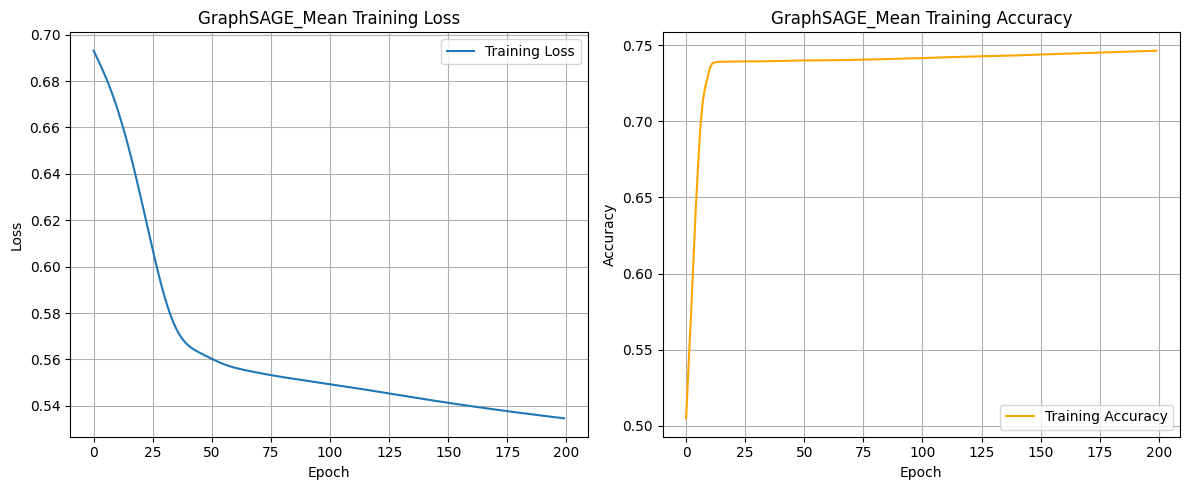

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plotting loss for GraphSAGE_Mean
plt.subplot(1, 2, 1)
plt.plot(mean_losses, label='Training Loss')
plt.title('GraphSAGE_Mean Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting accuracy for GraphSAGE_Mean
plt.subplot(1, 2, 2)
plt.plot(mean_accuracies, label='Training Accuracy', color='orange')
plt.title('GraphSAGE_Mean Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

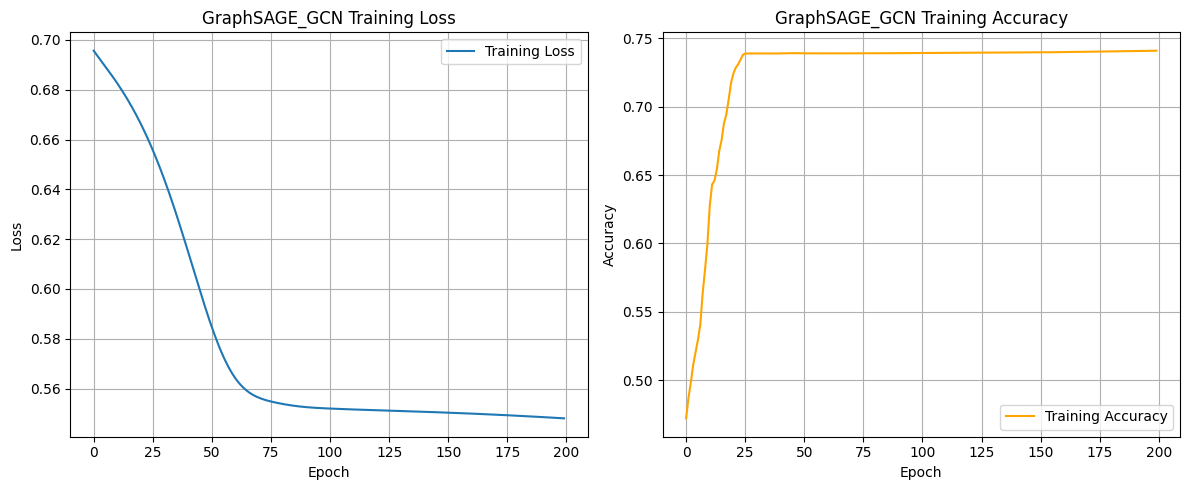

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plotting loss for GraphSAGE_GCN
plt.subplot(1, 2, 1)
plt.plot(gcn_losses, label='Training Loss')
plt.title('GraphSAGE_GCN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting accuracy for GraphSAGE_GCN
plt.subplot(1, 2, 2)
plt.plot(gcn_accuracies, label='Training Accuracy', color='orange')
plt.title('GraphSAGE_GCN Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()